In [1]:
from pathlib import Path
from collections import defaultdict
import hashlib

UEC_ROOT = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/UECFOOD256"
)

SELECTED_CLASSES = {
    1: "rice",
    7: "sushi",
    9: "fried rice",
    12: "toast",
    13: "croissant",
    17: "hamburger",
    18: "pizza",
    19: "sandwiches",
    23: "ramen noodle",
    27: "spaghetti",
    30: "gratin",
    36: "miso soup",
    38: "sausage",
    40: "omelet",
    46: "grilled salmon",
    55: "fried chicken",
    61: "steak",
    68: "egg sunny-side up",
    80: "roast chicken",
    86: "potato salad",
    87: "green salad",
    94: "rice ball",
    97: "hot dog",
    98: "french fries",
    114: "pancake",
    123: "mushroom risotto",
    130: "chicken nugget",
    151: "scrambled egg",
    153: "lasagna",
    224: "brownie",
}

hash_groups = defaultdict(list)

total_files = 0

for class_id in SELECTED_CLASSES:

    class_dir = UEC_ROOT / str(class_id)

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() not in [
            ".jpg", ".jpeg", ".png"
        ]:
            continue

        total_files += 1

        with open(image_path, "rb") as f:
            h = hashlib.sha256(f.read()).hexdigest()

        hash_groups[h].append(
            {
                "class_id": class_id,
                "filename": image_path.name,
                "path": image_path
            }
        )


duplicate_groups = {
    h: items
    for h, items in hash_groups.items()
    if len(items) > 1
}


print("Total source image files:", total_files)
print("Unique physical/exact images:", len(hash_groups))
print("Duplicate groups:", len(duplicate_groups))

print("\nLargest duplicate groups:")

largest = sorted(
    duplicate_groups.values(),
    key=len,
    reverse=True
)

for group in largest[:15]:

    print("\nCopies:", len(group))

    for item in group:
        print(
            item["class_id"],
            SELECTED_CLASSES[item["class_id"]],
            item["filename"]
        )

Total source image files: 5569
Unique physical/exact images: 4774
Duplicate groups: 601

Largest duplicate groups:

Copies: 7
1 rice 11161.jpg
1 rice 11156.jpg
36 miso soup 11161.jpg
36 miso soup 11156.jpg
55 fried chicken 11156.jpg
98 french fries 11161.jpg
98 french fries 11156.jpg

Copies: 6
1 rice 14621.jpg
1 rice 14505.jpg
36 miso soup 14621.jpg
36 miso soup 14505.jpg
87 green salad 14621.jpg
87 green salad 14505.jpg

Copies: 6
1 rice 14592.jpg
1 rice 14372.jpg
36 miso soup 14592.jpg
36 miso soup 14372.jpg
87 green salad 14592.jpg
87 green salad 14372.jpg

Copies: 6
1 rice 13822.jpg
1 rice 14607.jpg
36 miso soup 13822.jpg
36 miso soup 14607.jpg
46 grilled salmon 13822.jpg
46 grilled salmon 14607.jpg

Copies: 5
1 rice 14595.jpg
1 rice 13938.jpg
36 miso soup 14595.jpg
36 miso soup 13938.jpg
46 grilled salmon 13938.jpg

Copies: 5
1 rice 14596.jpg
1 rice 13948.jpg
36 miso soup 14596.jpg
36 miso soup 13948.jpg
86 potato salad 14596.jpg

Copies: 5
1 rice 13819.jpg
1 rice 14605.jpg
36 mi

In [4]:
from pathlib import Path
from collections import defaultdict, Counter
import hashlib
import random
import shutil
import cv2
import math

# ============================================================
# PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection"
)

UEC_ROOT = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/UECFOOD256"
)

OLD_FOOD41 = PROJECT_ROOT / "food41_yolo"
NEW_DATASET = PROJECT_ROOT / "food41_yolo_clean"


# ============================================================
# UEC CLASSES
# ============================================================

SELECTED_CLASSES = {
    1: "rice",
    7: "sushi",
    9: "fried rice",
    12: "toast",
    13: "croissant",
    17: "hamburger",
    18: "pizza",
    19: "sandwiches",
    23: "ramen noodle",
    27: "spaghetti",
    30: "gratin",
    36: "miso soup",
    38: "sausage",
    40: "omelet",
    46: "grilled salmon",
    55: "fried chicken",
    61: "steak",
    68: "egg sunny-side up",
    80: "roast chicken",
    86: "potato salad",
    87: "green salad",
    94: "rice ball",
    97: "hot dog",
    98: "french fries",
    114: "pancake",
    123: "mushroom risotto",
    130: "chicken nugget",
    151: "scrambled egg",
    153: "lasagna",
    224: "brownie",
}


# UEC ID -> YOLO ID
UEC_TO_YOLO = {
    uec_id: yolo_id
    for yolo_id, uec_id in enumerate(SELECTED_CLASSES.keys())
}


FINAL_CLASS_NAMES = {
    0: "rice",
    1: "sushi",
    2: "fried rice",
    3: "toast",
    4: "croissant",
    5: "hamburger",
    6: "pizza",
    7: "sandwiches",
    8: "ramen noodle",
    9: "spaghetti",
    10: "gratin",
    11: "miso soup",
    12: "sausage",
    13: "omelet",
    14: "grilled salmon",
    15: "fried chicken",
    16: "steak",
    17: "egg sunny-side up",
    18: "roast chicken",
    19: "potato salad",
    20: "green salad",
    21: "rice ball",
    22: "hot dog",
    23: "french fries",
    24: "pancake",
    25: "mushroom risotto",
    26: "chicken nugget",
    27: "scrambled egg",
    28: "lasagna",
    29: "brownie",

    30: "apple",
    31: "banana",
    32: "tomato",
    33: "lemon",
    34: "litchi",
    35: "mango",
    36: "orange",
    37: "peach",
    38: "pear",
    39: "plum",
    40: "kiwi",
}


# ============================================================
# CREATE OUTPUT STRUCTURE
# ============================================================

if NEW_DATASET.exists():
    shutil.rmtree(NEW_DATASET)

for split in ["train", "val", "test"]:
    (NEW_DATASET / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )
    (NEW_DATASET / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

print("Created:", NEW_DATASET)


# ============================================================
# READ ALL UEC bb_info.txt FILES
# ============================================================

# annotations[uec_class_id][image_stem]
# -> list of (x1,y1,x2,y2)

annotations = defaultdict(lambda: defaultdict(list))

for uec_id in SELECTED_CLASSES:

    bb_path = UEC_ROOT / str(uec_id) / "bb_info.txt"

    with open(
        bb_path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            # Skip header
            if not parts[0].replace(".", "").isdigit():
                continue

            image_id = Path(parts[0]).stem

            try:
                x1, y1, x2, y2 = map(
                    float,
                    parts[1:]
                )
            except ValueError:
                continue

            annotations[uec_id][image_id].append(
                (x1, y1, x2, y2)
            )

print("UEC annotations loaded.")


# ============================================================
# HASH ORIGINAL UEC IMAGES
# ============================================================

hash_groups = defaultdict(list)

for uec_id in SELECTED_CLASSES:

    class_dir = UEC_ROOT / str(uec_id)

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() not in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:
            continue

        with open(image_path, "rb") as f:
            h = hashlib.sha256(f.read()).hexdigest()

        hash_groups[h].append(
            {
                "uec_id": uec_id,
                "image_path": image_path,
                "image_stem": image_path.stem
            }
        )


print("Unique UEC images:", len(hash_groups))


# ============================================================
# IoU HELPER
# Used to avoid duplicate copies of almost identical boxes
# for the same class.
# ============================================================

def bbox_iou(a, b):

    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)

    inter = iw * ih

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - inter

    if union <= 0:
        return 0

    return inter / union


# ============================================================
# MERGE ANNOTATIONS FOR EACH UNIQUE IMAGE
# ============================================================

samples = []

missing_annotations = 0
invalid_images = 0
removed_duplicate_boxes = 0


for image_hash, copies in hash_groups.items():

    representative = copies[0]["image_path"]

    image = cv2.imread(str(representative))

    if image is None:
        invalid_images += 1
        continue

    height, width = image.shape[:2]

    merged_boxes = []

    for item in copies:

        uec_id = item["uec_id"]
        stem = item["image_stem"]

        yolo_id = UEC_TO_YOLO[uec_id]

        boxes = annotations[uec_id].get(stem, [])

        if not boxes:
            missing_annotations += 1
            continue

        for box in boxes:

            x1, y1, x2, y2 = box

            # Clip
            x1 = max(0, min(x1, width))
            y1 = max(0, min(y1, height))
            x2 = max(0, min(x2, width))
            y2 = max(0, min(y2, height))

            if x2 <= x1 or y2 <= y1:
                continue

            # Avoid duplicate same-class boxes
            duplicate = False

            for existing in merged_boxes:

                existing_class = existing[0]
                existing_box = existing[1]

                if (
                    existing_class == yolo_id
                    and bbox_iou(
                        (x1, y1, x2, y2),
                        existing_box
                    ) >= 0.98
                ):
                    duplicate = True
                    break

            if duplicate:
                removed_duplicate_boxes += 1
                continue

            merged_boxes.append(
                (
                    yolo_id,
                    (x1, y1, x2, y2)
                )
            )


    if not merged_boxes:
        continue


    classes_present = sorted(
        set(class_id for class_id, _ in merged_boxes)
    )

    samples.append(
        {
            "hash": image_hash,
            "image_path": representative,
            "width": width,
            "height": height,
            "boxes": merged_boxes,
            "classes": classes_present
        }
    )


print("\nMerged UEC samples:", len(samples))
print("Invalid images:", invalid_images)
print("Missing annotation references:", missing_annotations)
print(
    "Duplicate same-class boxes removed:",
    removed_duplicate_boxes
)


# ============================================================
# MULTI-LABEL GROUP-AWARE SPLIT
#
# Goal:
# approximately 64% train / 16% val / 20% test
#
# Since every unique physical image is represented only once,
# leakage between splits becomes impossible.
# ============================================================

RATIOS = {
    "train": 0.64,
    "val": 0.16,
    "test": 0.20
}

random.seed(42)


# Number of unique images containing each class
class_presence = Counter()

for sample in samples:
    for class_id in sample["classes"]:
        class_presence[class_id] += 1


target_total = {
    split: len(samples) * ratio
    for split, ratio in RATIOS.items()
}


target_class = {
    split: {
        class_id: class_presence[class_id] * ratio
        for class_id in range(30)
    }
    for split, ratio in RATIOS.items()
}


current_total = Counter()

current_class = {
    split: Counter()
    for split in RATIOS
}


assignments = {
    split: []
    for split in RATIOS
}


# Rare/multi-label samples first
def rarity_score(sample):

    score = 0

    for class_id in sample["classes"]:
        score += 1 / max(
            class_presence[class_id],
            1
        )

    return score


random.shuffle(samples)

samples.sort(
    key=lambda s: (
        len(s["classes"]),
        rarity_score(s)
    ),
    reverse=True
)


for sample in samples:

    best_split = None
    best_score = None

    for split in RATIOS:

        # Overall remaining capacity
        total_deficit = (
            target_total[split]
            - current_total[split]
        )

        total_component = (
            total_deficit
            / max(target_total[split], 1)
        )

        # Per-class remaining capacity
        class_component = 0

        for class_id in sample["classes"]:

            target = target_class[split][class_id]
            current = current_class[split][class_id]

            deficit = target - current

            class_component += (
                deficit / max(target, 1)
            )

        # Class balancing is more important
        score = (
            2.0 * class_component
            + 0.5 * total_component
        )

        # Discourage overshooting split size too much
        if (
            current_total[split]
            >= math.ceil(target_total[split])
        ):
            score -= 10

        if (
            best_score is None
            or score > best_score
        ):
            best_score = score
            best_split = split


    assignments[best_split].append(sample)

    current_total[best_split] += 1

    for class_id in sample["classes"]:
        current_class[best_split][class_id] += 1


# ============================================================
# WRITE CLEAN UEC DATASET
# ============================================================

uec_objects_per_split = Counter()
uec_images_per_split = Counter()


for split, split_samples in assignments.items():

    for sample in split_samples:

        image_path = sample["image_path"]

        # unique filename based on image hash
        filename = (
            f"uec_{sample['hash'][:20]}.jpg"
        )

        output_image = (
            NEW_DATASET
            / "images"
            / split
            / filename
        )

        output_label = (
            NEW_DATASET
            / "labels"
            / split
            / Path(filename).with_suffix(".txt")
        )


        # Copy image
        shutil.copy2(
            image_path,
            output_image
        )


        width = sample["width"]
        height = sample["height"]

        label_lines = []

        for class_id, box in sample["boxes"]:

            x1, y1, x2, y2 = box

            x_center = (
                ((x1 + x2) / 2) / width
            )

            y_center = (
                ((y1 + y2) / 2) / height
            )

            box_width = (
                (x2 - x1) / width
            )

            box_height = (
                (y2 - y1) / height
            )

            label_lines.append(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{box_width:.6f} "
                f"{box_height:.6f}"
            )


        output_label.write_text(
            "\n".join(label_lines) + "\n"
        )

        uec_images_per_split[split] += 1

        uec_objects_per_split[split] += len(
            sample["boxes"]
        )


# ============================================================
# COPY CLEAN ECUSTFD PORTION FROM EXISTING food41_yolo
# ============================================================

ecust_counts = Counter()

for split in ["train", "val", "test"]:

    old_image_dir = (
        OLD_FOOD41 / "images" / split
    )

    old_label_dir = (
        OLD_FOOD41 / "labels" / split
    )

    for image_path in old_image_dir.glob(
        "ecust_*"
    ):

        label_path = (
            old_label_dir
            / f"{image_path.stem}.txt"
        )

        if not label_path.exists():
            raise FileNotFoundError(
                f"Missing ECUST label: {label_path}"
            )

        shutil.copy2(
            image_path,
            NEW_DATASET
            / "images"
            / split
            / image_path.name
        )

        shutil.copy2(
            label_path,
            NEW_DATASET
            / "labels"
            / split
            / label_path.name
        )

        ecust_counts[split] += 1


# ============================================================
# WRITE dataset.yaml
# ============================================================

yaml_lines = [
    "path: /content/food41_yolo_clean",
    "",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "",
    "names:"
]

for class_id in range(41):

    yaml_lines.append(
        f"  {class_id}: {FINAL_CLASS_NAMES[class_id]}"
    )

(
    NEW_DATASET / "dataset.yaml"
).write_text(
    "\n".join(yaml_lines) + "\n",
    encoding="utf-8"
)


# ============================================================
# WRITE CLASS MAPPING
# ============================================================

mapping_lines = []

for class_id in range(41):
    mapping_lines.append(
        f"{class_id}: {FINAL_CLASS_NAMES[class_id]}"
    )

(
    NEW_DATASET / "class_mapping.txt"
).write_text(
    "\n".join(mapping_lines) + "\n",
    encoding="utf-8"
)


# ============================================================
# FINAL REPORT
# ============================================================

print("\n======================================")
print("UEC CLEAN SPLIT")
print("======================================")

for split in ["train", "val", "test"]:

    print(
        f"{split:<5} "
        f"images={uec_images_per_split[split]:4d} "
        f"objects={uec_objects_per_split[split]:4d}"
    )


print("\n======================================")
print("ECUSTFD COPIED")
print("======================================")

for split in ["train", "val", "test"]:

    print(
        f"{split:<5} images={ecust_counts[split]}"
    )


print("\n======================================")
print("FINAL DATASET")
print("======================================")

for split in ["train", "val", "test"]:

    image_dir = NEW_DATASET / "images" / split
    label_dir = NEW_DATASET / "labels" / split

    images = [
        p for p in image_dir.iterdir()
        if p.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]
    ]

    labels = list(
        label_dir.glob("*.txt")
    )

    print(
        f"{split:<5} "
        f"images={len(images):4d} "
        f"labels={len(labels):4d}"
    )


print("\nDataset:")
print(NEW_DATASET)

print("\nYAML:")
print(NEW_DATASET / "dataset.yaml")

print("\n✓ CLEAN DATASET BUILD COMPLETE")

Created: /Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food41_yolo_clean
UEC annotations loaded.
Unique UEC images: 4774

Merged UEC samples: 4774
Invalid images: 0
Missing annotation references: 0
Duplicate same-class boxes removed: 9

UEC CLEAN SPLIT
train images=3055 objects=3653
val   images= 764 objects= 928
test  images= 955 objects=1137

ECUSTFD COPIED
train images=1223
val   images=304
test  images=407

FINAL DATASET
train images=4278 labels=4278
val   images=1068 labels=1068
test  images=1362 labels=1362

Dataset:
/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food41_yolo_clean

YAML:
/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food41_yolo_clean/dataset.yaml

✓ CLEAN DATASET BUILD COMPLETE


In [5]:
from pathlib import Path
from collections import defaultdict
import hashlib

DATASET = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food41_yolo_clean"
)

hash_locations = defaultdict(list)

for split in ["train", "val", "test"]:

    image_dir = DATASET / "images" / split

    for image_path in image_dir.iterdir():

        if image_path.suffix.lower() not in [
            ".jpg", ".jpeg", ".png"
        ]:
            continue

        with open(image_path, "rb") as f:
            h = hashlib.sha256(f.read()).hexdigest()

        hash_locations[h].append(
            (split, image_path.name)
        )


cross_split = {}

for h, locations in hash_locations.items():

    splits = {
        split
        for split, _ in locations
    }

    if len(splits) > 1:
        cross_split[h] = locations


print("Unique image hashes:", len(hash_locations))
print(
    "Cross-split duplicate groups:",
    len(cross_split)
)

if cross_split:
    print("\nExamples:")

    for locations in list(
        cross_split.values()
    )[:10]:
        print(locations)

else:
    print("\n✓ NO CROSS-SPLIT IMAGE LEAKAGE")

Unique image hashes: 6708
Cross-split duplicate groups: 0

✓ NO CROSS-SPLIT IMAGE LEAKAGE


Multi-class UEC images: 531


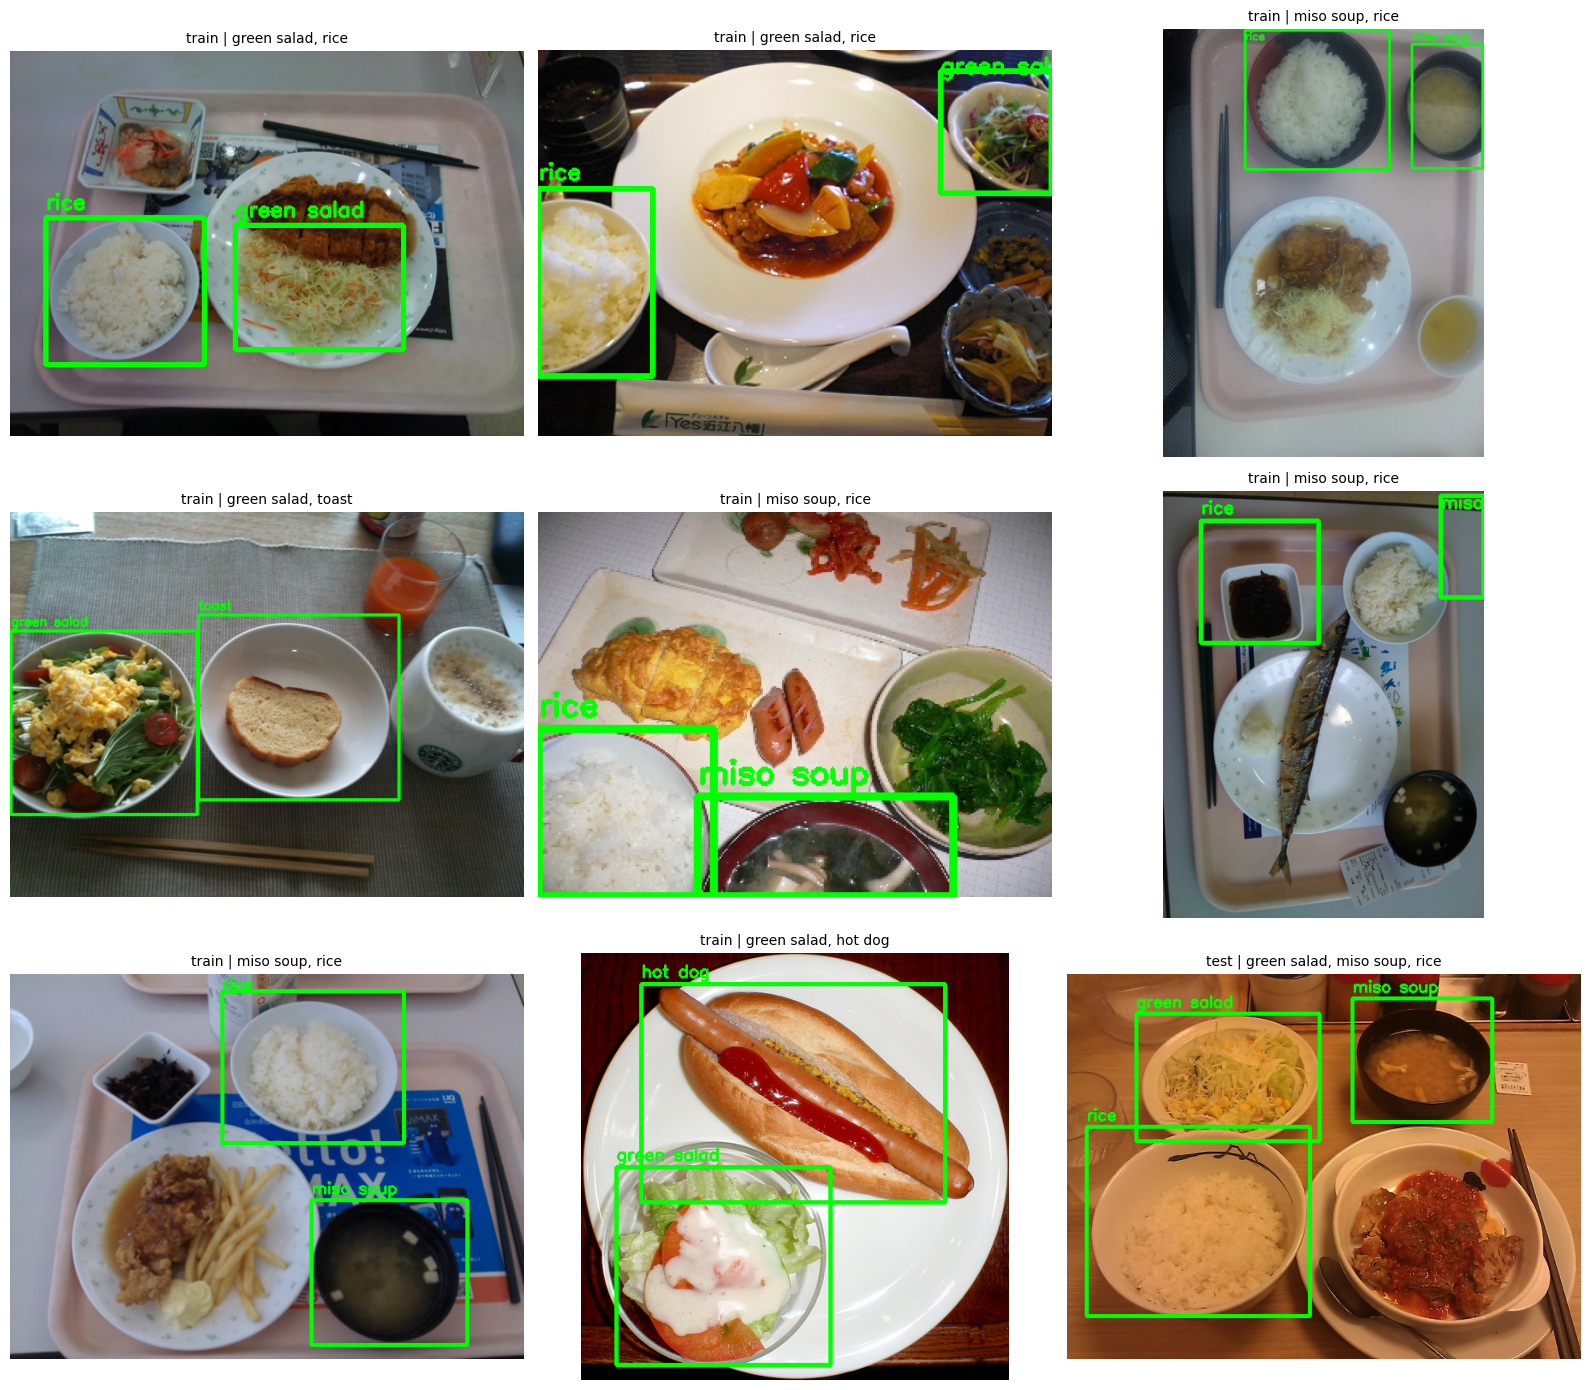

In [6]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

DATASET = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food41_yolo_clean"
)

CLASS_NAMES = {
    0: "rice",
    1: "sushi",
    2: "fried rice",
    3: "toast",
    4: "croissant",
    5: "hamburger",
    6: "pizza",
    7: "sandwiches",
    8: "ramen noodle",
    9: "spaghetti",
    10: "gratin",
    11: "miso soup",
    12: "sausage",
    13: "omelet",
    14: "grilled salmon",
    15: "fried chicken",
    16: "steak",
    17: "egg sunny-side up",
    18: "roast chicken",
    19: "potato salad",
    20: "green salad",
    21: "rice ball",
    22: "hot dog",
    23: "french fries",
    24: "pancake",
    25: "mushroom risotto",
    26: "chicken nugget",
    27: "scrambled egg",
    28: "lasagna",
    29: "brownie",
    30: "apple",
    31: "banana",
    32: "tomato",
    33: "lemon",
    34: "litchi",
    35: "mango",
    36: "orange",
    37: "peach",
    38: "pear",
    39: "plum",
    40: "kiwi",
}


multi_object_images = []

for split in ["train", "val", "test"]:

    label_dir = DATASET / "labels" / split

    for label_path in label_dir.glob("uec_*.txt"):

        lines = [
            line.strip()
            for line in label_path.read_text().splitlines()
            if line.strip()
        ]

        class_ids = {
            int(line.split()[0])
            for line in lines
        }

        # At least two different food classes
        if len(class_ids) >= 2:
            multi_object_images.append(
                (split, label_path.stem)
            )


print(
    "Multi-class UEC images:",
    len(multi_object_images)
)

random.seed(42)

samples = random.sample(
    multi_object_images,
    min(9, len(multi_object_images))
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 14)
)

axes = axes.flatten()


for ax, (split, stem) in zip(
    axes,
    samples
):

    image_path = (
        DATASET
        / "images"
        / split
        / f"{stem}.jpg"
    )

    label_path = (
        DATASET
        / "labels"
        / split
        / f"{stem}.txt"
    )

    image = cv2.imread(
        str(image_path)
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    h, w = image.shape[:2]

    classes_found = []

    for line in label_path.read_text().splitlines():

        parts = line.split()

        class_id = int(parts[0])

        xc, yc, bw, bh = map(
            float,
            parts[1:]
        )

        xc *= w
        yc *= h
        bw *= w
        bh *= h

        x1 = int(xc - bw / 2)
        y1 = int(yc - bh / 2)
        x2 = int(xc + bw / 2)
        y2 = int(yc + bh / 2)

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            3
        )

        label = CLASS_NAMES[class_id]

        classes_found.append(label)

        cv2.putText(
            image,
            label,
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (0, 255, 0),
            2
        )

    ax.imshow(image)

    ax.set_title(
        f"{split} | "
        + ", ".join(sorted(set(classes_found))),
        fontsize=10
    )

    ax.axis("off")


plt.tight_layout()
plt.show()